In [435]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset (id=938)
regensburg_pediatric_appendicitis = fetch_ucirepo(id=938)

# Features and targets as pandas DataFrames
X = regensburg_pediatric_appendicitis.data.features
y = regensburg_pediatric_appendicitis.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.head())

(782, 56)
     Age   BMI     Sex  Height  Weight  Length_of_Stay  Alvarado_Score  \
0  12.68  16.9  female   148.0    37.0             3.0             4.0   
1  14.10  31.9    male   147.0    69.5             2.0             5.0   
2  14.14  23.3  female   163.0    62.0             4.0             5.0   
3  16.37  20.6  female   165.0    56.0             3.0             7.0   
4  11.08  16.9  female   163.0    45.0             3.0             5.0   

   Paedriatic_Appendicitis_Score Appendix_on_US  Appendix_Diameter  ...  \
0                            3.0            yes                7.1  ...   
1                            4.0             no                NaN  ...   
2                            3.0             no                NaN  ...   
3                            6.0             no                NaN  ...   
4                            6.0            yes                7.0  ...   

  Bowel_Wall_Thickening Conglomerate_of_Bowel_Loops Ileus Coprostasis  \
0                   N

In [436]:
# check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    str    
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    777 non-null    str    
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    str    
 11  Lower_Right_Abd_Pain              774 non-null    str    
 12  Contralateral_Rebou

In [437]:
# percentage of missing values per column
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent)


Abscess_Location                    98.337596
Gynecological_Findings              96.675192
Conglomerate_of_Bowel_Loops         94.501279
Segmented_Neutrophils               93.094629
Ileus                               92.327366
Perfusion                           91.943734
Enteritis                           91.560102
Appendicolith                       91.176471
Coprostasis                         90.920716
Perforation                         89.641944
Appendicular_Abscess                89.130435
Bowel_Wall_Thickening               87.340153
Lymph_Nodes_Location                84.526854
Target_Sign                         82.352941
Meteorism                           82.097187
Pathological_Lymph_Nodes            74.040921
Appendix_Wall_Layers                72.122762
Surrounding_Tissue_Reaction         67.774936
Appendix_Diameter                   36.317136
RBC_in_Urine                        26.342711
Ketones_in_Urine                    25.575448
WBC_in_Urine                      

In [438]:
# Drop rows with missing target (Diagnosis)
df = df.dropna(subset = ["Diagnosis"])

print(df.shape)
print(df["Diagnosis"].value_counts())

(780, 56)
Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64


In [439]:
# Count fully duplicated rows
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [440]:
# Drop columns with more than 70% missing values

high_missing = missing_percent[missing_percent > 70].index.tolist()
print(len(high_missing), high_missing)

# Drop them
df = df.drop(columns=high_missing)

print(df.shape)

17 ['Abscess_Location', 'Gynecological_Findings', 'Conglomerate_of_Bowel_Loops', 'Segmented_Neutrophils', 'Ileus', 'Perfusion', 'Enteritis', 'Appendicolith', 'Coprostasis', 'Perforation', 'Appendicular_Abscess', 'Bowel_Wall_Thickening', 'Lymph_Nodes_Location', 'Target_Sign', 'Meteorism', 'Pathological_Lymph_Nodes', 'Appendix_Wall_Layers']
(780, 39)


In [441]:
# Management and Severity are outcomes decided after diagnosis, so they leak the answer
leak_cols = ["Diagnosis", "Management", "Severity", "Length_of_Stay"]
strict_drop = leak_cols + ["Alvarado_Score", "Paedriatic_Appendicitis_Score", "Appendix_Diameter"]
X = df.drop(columns=strict_drop, errors="ignore")
y = df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (780, 32)
Target shape: (780,)


In [442]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training rows: 624
Testing rows: 156
Diagnosis
appendicitis       0.592949
no appendicitis    0.407051
Name: proportion, dtype: float64
Diagnosis
appendicitis       0.596154
no appendicitis    0.403846
Name: proportion, dtype: float64


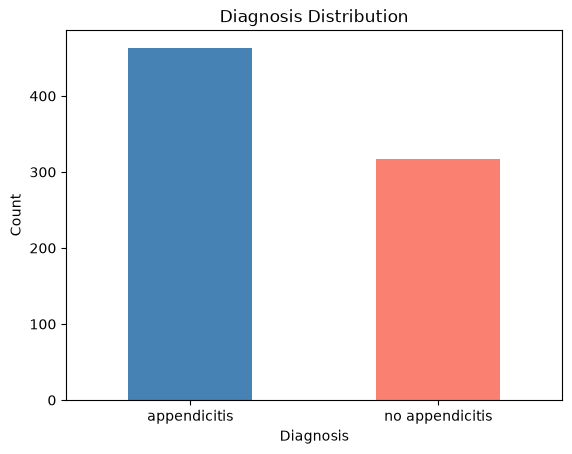

In [443]:
import matplotlib.pyplot as plt

# Bar plot of Diagnosis classes
df["Diagnosis"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

12 ['Age', 'BMI', 'Height', 'Weight', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


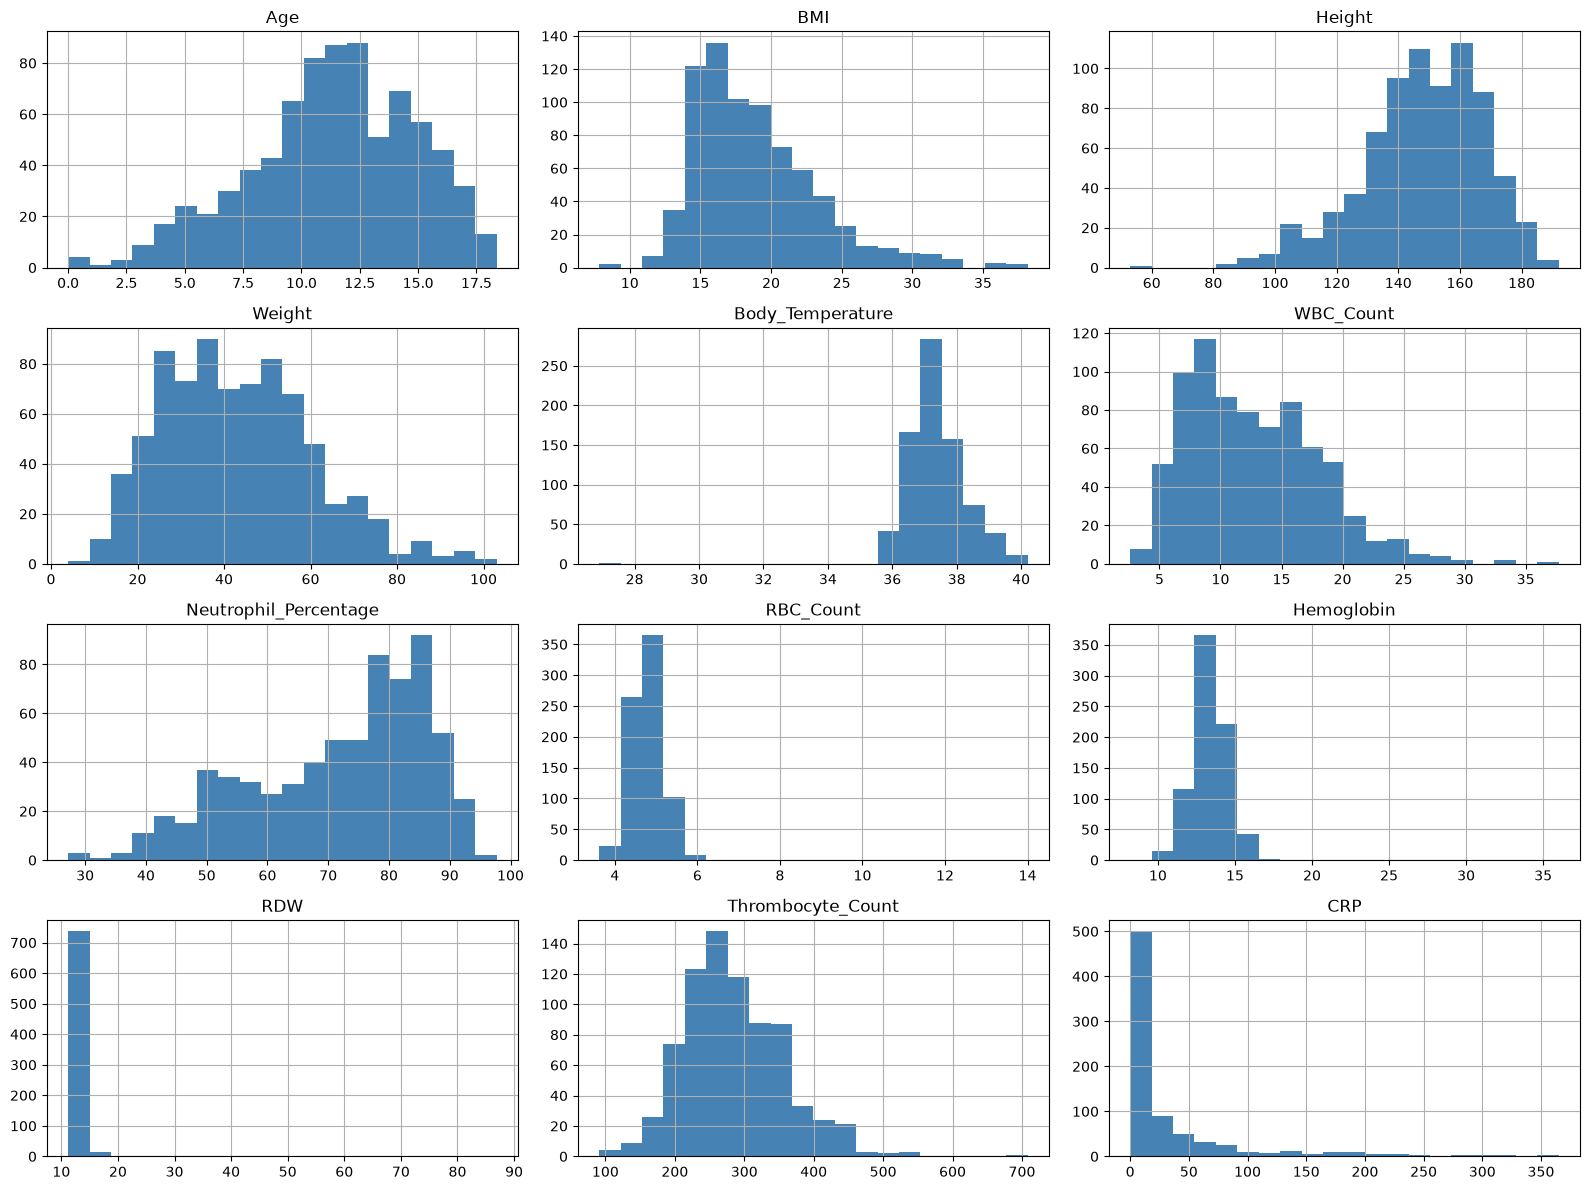

In [444]:
# Numerical columns only
num_cols = X.select_dtypes(include="number").columns.tolist()
print(len(num_cols), num_cols)

# Histogram for each numerical feature
df[num_cols].hist(bins=20, figsize=(16, 12), color="steelblue")
plt.tight_layout()
plt.show()

In [445]:
# Summary statistics of numerical features
print(df[num_cols].describe().T.round(2))

# Skewness values (positive = right-skewed, negative = left-skewed)
print(df[num_cols].skew().round(2))

                       count    mean    std    min     25%     50%     75%  \
Age                    780.0   11.34   3.53   0.00    9.20   11.44   14.04   
BMI                    754.0   18.91   4.39   7.83   15.72   18.05   21.18   
Height                 755.0  148.00  19.74  53.00  137.00  149.50  163.00   
Weight                 778.0   43.16  17.40   3.96   29.50   41.30   54.00   
Body_Temperature       775.0   37.40   0.90  26.90   36.80   37.20   37.90   
WBC_Count              776.0   12.67   5.37   2.60    8.20   12.00   16.20   
Neutrophil_Percentage  679.0   71.79  14.46  27.20   61.40   75.50   83.60   
RBC_Count              764.0    4.80   0.50   3.62    4.54    4.78    5.02   
Hemoglobin             764.0   13.38   1.39   8.20   12.60   13.30   14.00   
RDW                    756.0   13.18   4.54  11.20   12.30   12.70   13.30   
Thrombocyte_Count      764.0  285.25  72.49  91.00  236.00  276.00  330.00   
CRP                    771.0   31.39  57.43   0.00    1.00    7.

In [446]:
# Count outliers per numerical feature using the IQR rule
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "->", n_out, "outliers")

Age -> 5 outliers
BMI -> 23 outliers
Height -> 12 outliers
Weight -> 8 outliers
Body_Temperature -> 12 outliers
WBC_Count -> 6 outliers
Neutrophil_Percentage -> 1 outliers
RBC_Count -> 14 outliers
Hemoglobin -> 16 outliers
RDW -> 23 outliers
Thrombocyte_Count -> 9 outliers
CRP -> 85 outliers


In [447]:
print(df.groupby("Diagnosis")["CRP"].describe())
df.loc[df["CRP"] > df["CRP"].quantile(0.75) + 1.5*(df["CRP"].quantile(0.75)-df["CRP"].quantile(0.25)), "Diagnosis"].value_counts()

                 count       mean        std  min  25%   50%    75%    max
Diagnosis                                                                 
appendicitis     457.0  44.902188  68.515050  0.0  3.0  16.0  51.00  365.0
no appendicitis  314.0  11.716561  24.920434  0.0  0.0   1.0  10.75  235.0


Diagnosis
appendicitis       80
no appendicitis     5
Name: count, dtype: int64

In [448]:
df["CRP_log"] = np.log1p(df["CRP"])

In [449]:
print(df[["BMI", "Height", "Weight", "Body_Temperature", "Hemoglobin"]].describe())

              BMI      Height      Weight  Body_Temperature  Hemoglobin
count  754.000000  755.000000  778.000000        775.000000  764.000000
mean    18.905138  147.997616   43.158625         37.404516   13.380497
std      4.387940   19.737546   17.397830          0.903678    1.393271
min      7.830000   53.000000    3.960000         26.900000    8.200000
25%     15.722500  137.000000   29.500000         36.800000   12.600000
50%     18.045000  149.500000   41.300000         37.200000   13.300000
75%     21.185000  163.000000   54.000000         37.900000   14.000000
max     38.160000  192.000000  103.000000         40.200000   36.000000


In [450]:
cols = ["Age", "WBC_Count", "Neutrophil_Percentage", "RBC_Count", "RDW", "Thrombocyte_Count"]
print(df[cols].describe().T[["min", "max"]])
print(df[["Age"]].nsmallest(5, "Age"))

                         min     max
Age                     0.00   18.36
WBC_Count               2.60   37.70
Neutrophil_Percentage  27.20   97.70
RBC_Count               3.62   14.00
RDW                    11.20   86.90
Thrombocyte_Count      91.00  708.00
      Age
656  0.00
676  0.04
638  0.53
405  0.85
303  1.73


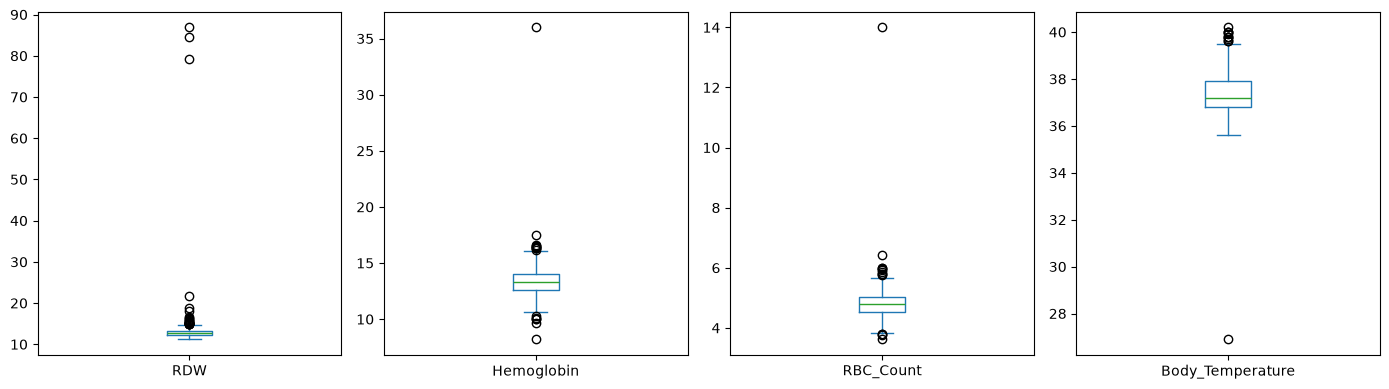

In [451]:
# Boxplots of columns with impossible-looking values
suspect_cols = ["RDW", "Hemoglobin", "RBC_Count", "Body_Temperature"]

df[suspect_cols].plot(kind="box", subplots=True, layout=(1, 4), figsize=(14, 4))
plt.tight_layout()
plt.show()

In [452]:
# Count impossible values (fixed medical limits, not learned from data)
print("RDW > 30:", (df["RDW"] > 30).sum())
print("Hemoglobin > 20:", (df["Hemoglobin"] > 20).sum())
print("RBC_Count > 8:", (df["RBC_Count"] > 8).sum())
print("Body_Temperature < 30:", (df["Body_Temperature"] < 30).sum())

# Replace them with NaN so imputation handles them later
df.loc[df["RDW"] > 30, "RDW"] = np.nan
df.loc[df["Hemoglobin"] > 20, "Hemoglobin"] = np.nan
df.loc[df["RBC_Count"] > 8, "RBC_Count"] = np.nan
df.loc[df["Body_Temperature"] < 30, "Body_Temperature"] = np.nan

print(df[suspect_cols].describe().T.round(2))

RDW > 30: 3
Hemoglobin > 20: 1
RBC_Count > 8: 1
Body_Temperature < 30: 1
                  count   mean   std    min    25%    50%    75%    max
RDW               753.0  12.90  0.89  11.20  12.30  12.70  13.30  21.60
Hemoglobin        763.0  13.35  1.13   8.20  12.60  13.30  14.00  17.50
RBC_Count         763.0   4.79  0.37   3.62   4.54   4.78   5.02   6.44
Body_Temperature  774.0  37.42  0.82  35.60  36.80  37.20  37.90  40.20


In [453]:
# Re-split because df changed after the earlier split
X = df.drop(columns=strict_drop, errors="ignore")
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(X_train[suspect_cols].max().round(2))

Training rows: 624
Testing rows: 156
RDW                 21.6
Hemoglobin          17.5
RBC_Count            6.0
Body_Temperature    40.2
dtype: float64


In [454]:
# Categorical columns in the features
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print(len(cat_cols), cat_cols)

# Unique values per categorical column
for col in cat_cols:
    print(col, "->", X[col].unique())

20 ['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Surrounding_Tissue_Reaction']
Sex -> <ArrowStringArray>
['female', 'male', nan]
Length: 3, dtype: str
Appendix_on_US -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Migratory_Pain -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Lower_Right_Abd_Pain -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Contralateral_Rebound_Tenderness -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: str
Coughing_Pain -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Nausea -> <ArrowStringArray>
['no', 'yes', nan]
Length: 3, dtype: str
Loss_of_Appetite -> <ArrowStringArray>
['yes', 'no', nan]
Length: 3, dtype: st

In [455]:
# Group categorical columns by encoding type
ordinal_urine = ["Ketones_in_Urine", "RBC_in_Urine", "WBC_in_Urine"]
ordinal_peritonitis = ["Peritonitis"]
nominal_cols = ["Stool"]
binary_cols = [col for col in cat_cols
               if col not in ordinal_urine + ordinal_peritonitis + nominal_cols]

print(len(binary_cols), binary_cols)
print(len(ordinal_urine) + len(ordinal_peritonitis) + len(nominal_cols) + len(binary_cols))

15 ['Sex', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Dysuria', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids', 'Surrounding_Tissue_Reaction']
20


In [456]:
# Binary mapping for the target: appendicitis = 1, no appendicitis = 0
y_train = y_train.map({"no appendicitis": 0, "appendicitis": 1})
y_test = y_test.map({"no appendicitis": 0, "appendicitis": 1})

print(y_train.value_counts())
print(y_test.value_counts())

Diagnosis
1    370
0    254
Name: count, dtype: int64
Diagnosis
1    93
0    63
Name: count, dtype: int64


In [457]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Numerical columns (defined earlier as num_cols)
numeric_features = num_cols

numeric_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the median
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2: Standardise the completed values
    ("scaler", StandardScaler())
])

print(len(numeric_features), numeric_features)

12 ['Age', 'BMI', 'Height', 'Weight', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


In [458]:
from sklearn.preprocessing import OneHotEncoder

binary_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: One column per feature (drop="if_binary" keeps a single 0/1 column)
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

print(len(binary_cols))

15


In [459]:
from sklearn.preprocessing import OrdinalEncoder

# Order: no < + < ++ < +++
urine_order = ["no", "+", "++", "+++"]

urine_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: Encode in the natural order (one order list per column)
    ("encoder", OrdinalEncoder(
        categories=[urine_order] * len(ordinal_urine),
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

print(ordinal_urine)

['Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine']


In [460]:
# Order: no < local < generalized
peritonitis_order = ["no", "local", "generalized"]

peritonitis_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: Encode in the natural order
    ("encoder", OrdinalEncoder(
        categories=[peritonitis_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

print(ordinal_peritonitis)

['Peritonitis']


In [461]:
nominal_pipeline = Pipeline(steps=[
    # Step 1: Replace missing values with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: One-hot encode (no order between categories)
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print(nominal_cols)

['Stool']


In [462]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_cols),
    ("urine", urine_pipeline, ordinal_urine),
    ("peritonitis", peritonitis_pipeline, ordinal_peritonitis),
    ("nominal", nominal_pipeline, nominal_cols)
])

# Learn from training data only, then apply to test data
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Prepared training shape:", X_train_ready.shape)
print("Prepared testing shape:", X_test_ready.shape)

Prepared training shape: (624, 35)
Prepared testing shape: (156, 35)


In [463]:
train_df = df.loc[X_train.index]
print(train_df.shape)

(624, 40)


BMI                     -0.159
Weight                  -0.143
Age                     -0.115
Height                  -0.101
Hemoglobin              -0.033
RBC_Count               -0.005
RDW                      0.004
Thrombocyte_Count        0.010
Body_Temperature         0.136
CRP                      0.269
WBC_Count                0.356
Neutrophil_Percentage    0.366
dtype: float64


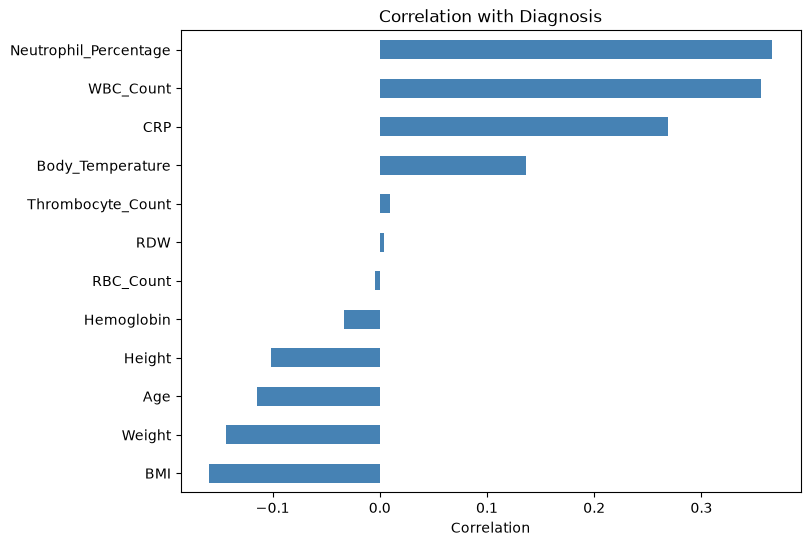

In [464]:
# Temporary numeric target (df itself stays unchanged)
target_num = train_df["Diagnosis"].map({"no appendicitis": 0, "appendicitis": 1})

# Correlation of each numerical feature with Diagnosis
corr_target = train_df[num_cols].corrwith(target_num).sort_values()
print(corr_target.round(3))

# Bar plot
corr_target.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Correlation with Diagnosis")
plt.xlabel("Correlation")
plt.show()

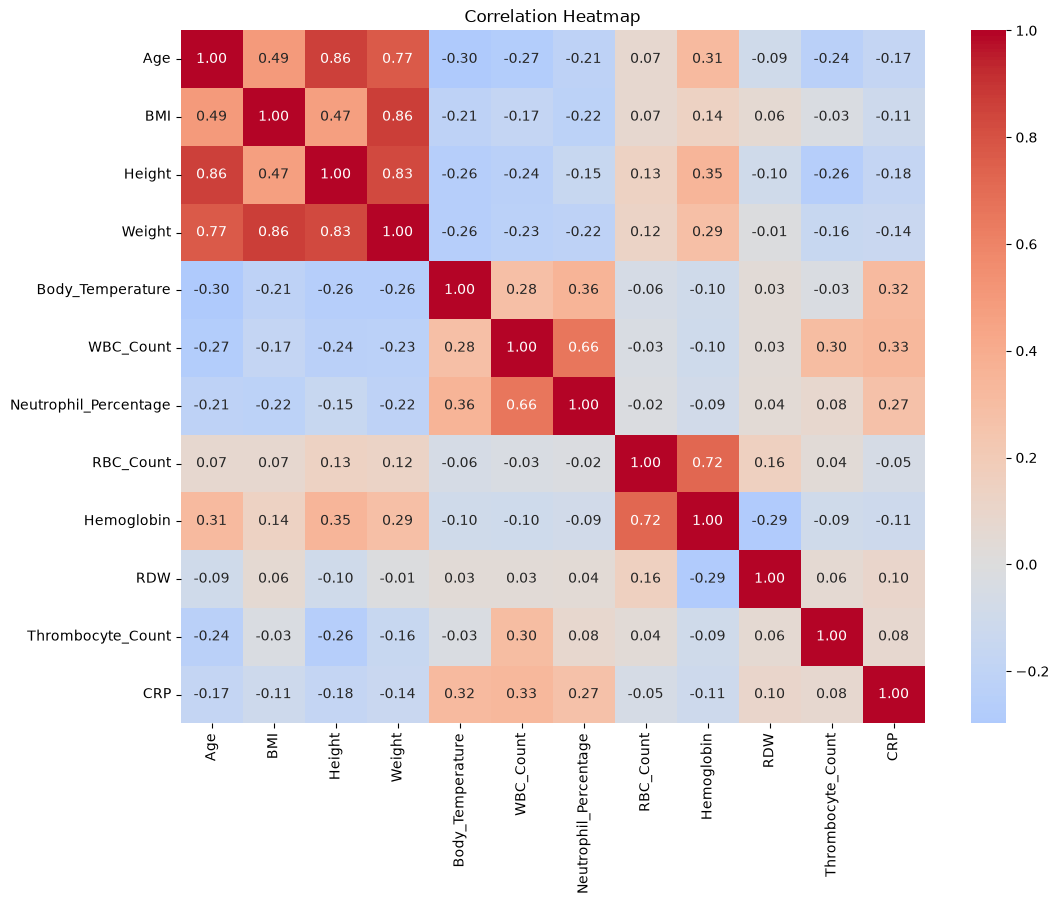

In [465]:
import seaborn as sns

# Correlation between numerical features (checks multicollinearity)
plt.figure(figsize=(12, 9))
sns.heatmap(train_df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [466]:
# Absolute correlation matrix, upper triangle only (avoids duplicate pairs)
corr_matrix = train_df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Pairs with correlation above 0.7
pairs = upper.stack()
print(pairs[pairs > 0.7].sort_values(ascending=False).round(2))

BMI        Weight        0.86
Age        Height        0.86
Height     Weight        0.83
Age        Weight        0.77
RBC_Count  Hemoglobin    0.72
dtype: float64


Sex -> {'female': 54.3, 'male': 64.2}
Appendix_on_US -> {'no': 27.7, 'yes': 76.3}
Migratory_Pain -> {'no': 55.7, 'yes': 67.6}
Lower_Right_Abd_Pain -> {'no': 29.4, 'yes': 60.9}
Contralateral_Rebound_Tenderness -> {'no': 52.6, 'yes': 68.8}
Coughing_Pain -> {'no': 55.8, 'yes': 66.3}
Nausea -> {'no': 49.8, 'yes': 65.5}
Loss_of_Appetite -> {'no': 52.0, 'yes': 65.4}
Neutrophilia -> {'no': 44.1, 'yes': 74.6}
Dysuria -> {'no': 58.5, 'yes': 48.8}
Psoas_Sign -> {'no': 60.4, 'yes': 53.4}
Ipsilateral_Rebound_Tenderness -> {'no': 48.1, 'yes': 72.4}
US_Performed -> {'no': 69.2, 'yes': 59.0}
Free_Fluids -> {'no': 50.6, 'yes': 71.8}
Surrounding_Tissue_Reaction -> {'no': 64.5, 'yes': 95.5}


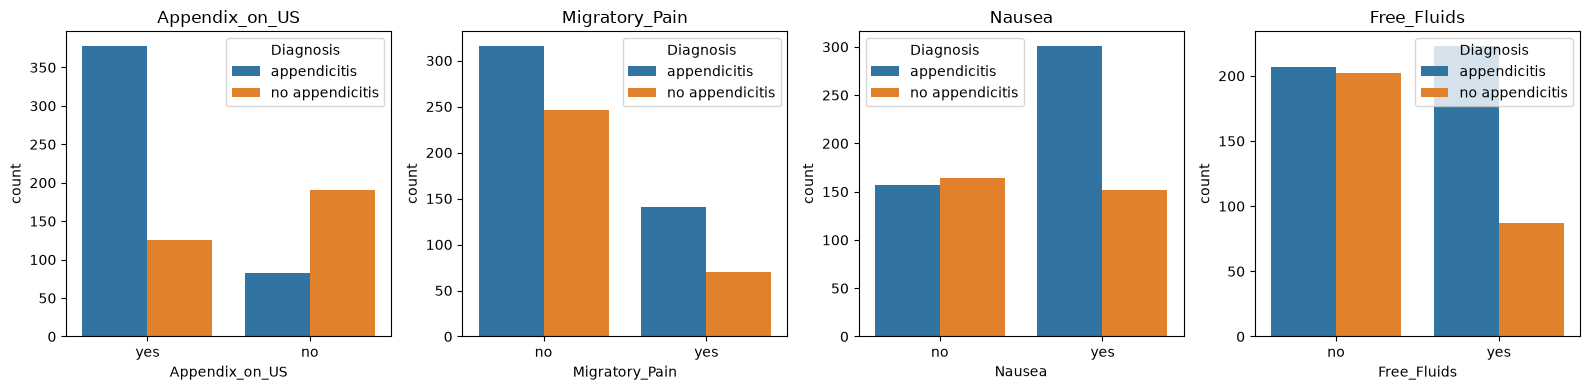

In [467]:
# Percentage of appendicitis cases for each category of each binary feature
for col in binary_cols:
    rate = train_df.groupby(col)["Diagnosis"].apply(lambda s: (s == "appendicitis").mean() * 100)
    print(col, "->", rate.round(1).to_dict())

# Plot a few key features
key_cols = ["Appendix_on_US", "Migratory_Pain", "Nausea", "Free_Fluids"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, key_cols):
    sns.countplot(data=df, x=col, hue="Diagnosis", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [468]:
from scipy.stats import chi2_contingency

# Chi-square test between each binary feature and Diagnosis
results = []
for col in binary_cols:
    table = pd.crosstab(train_df[col], train_df["Diagnosis"])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append([col, round(chi2, 2), round(p, 4)])

chi_df = pd.DataFrame(results, columns=["Feature", "Chi2", "p_value"])
print(chi_df.sort_values("p_value"))

                             Feature    Chi2  p_value
1                     Appendix_on_US  136.71   0.0000
14       Surrounding_Tissue_Reaction   25.31   0.0000
13                       Free_Fluids   25.21   0.0000
8                       Neutrophilia   55.18   0.0000
6                             Nausea   14.55   0.0001
4   Contralateral_Rebound_Tenderness   14.95   0.0001
3               Lower_Right_Abd_Pain   11.88   0.0006
7                   Loss_of_Appetite   10.86   0.0010
2                     Migratory_Pain    6.96   0.0083
0                                Sex    5.90   0.0151
11    Ipsilateral_Rebound_Tenderness    5.53   0.0187
5                      Coughing_Pain    5.20   0.0226
10                        Psoas_Sign    2.40   0.1211
9                            Dysuria    1.11   0.2927
12                      US_Performed    0.21   0.6496


In [469]:
from scipy.stats import mannwhitneyu

# Mann-Whitney U is used because several features are skewed
results = []
for col in num_cols:
    g1 = train_df.loc[train_df["Diagnosis"] == "appendicitis", col].dropna()
    g0 = train_df.loc[train_df["Diagnosis"] == "no appendicitis", col].dropna()
    stat, p = mannwhitneyu(g1, g0)
    results.append([col, round(g1.median(), 2), round(g0.median(), 2), round(p, 4)])

mw_df = pd.DataFrame(results, columns=["Feature", "Median_App", "Median_NoApp", "p_value"])
print(mw_df.sort_values("p_value"))

                  Feature  Median_App  Median_NoApp  p_value
6   Neutrophil_Percentage       79.45         66.40   0.0000
5               WBC_Count       14.30          9.00   0.0000
11                    CRP       15.00          1.00   0.0000
1                     BMI       17.56         19.05   0.0001
4        Body_Temperature       37.40         37.10   0.0001
3                  Weight       39.00         48.00   0.0002
0                     Age       11.31         12.06   0.0040
2                  Height      148.00        152.50   0.0107
8              Hemoglobin       13.30         13.35   0.4055
9                     RDW       12.80         12.70   0.6495
10      Thrombocyte_Count      275.00        273.00   0.8040
7               RBC_Count        4.78          4.77   0.9336


In [470]:
# Features to drop
drop_cols = ["RDW", "Hemoglobin", "RBC_Count", "Thrombocyte_Count", "Height",
             "Dysuria", "US_Performed", "Weight"]

# Update X and the train-test sets
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

# Update the column lists
numeric_features = [c for c in numeric_features if c not in drop_cols]
numeric_features.remove("CRP")
numeric_features.append("CRP_log")

print("CRP_log" in X_train.columns)
print("CRP_log" in numeric_features)
print("CRP" in numeric_features)

binary_cols = [c for c in binary_cols if c not in drop_cols]

# Rebuild the preprocessor with the updated lists
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_cols),
    ("urine", urine_pipeline, ordinal_urine),
    ("peritonitis", peritonitis_pipeline, ordinal_peritonitis),
    ("nominal", nominal_pipeline, nominal_cols)
], sparse_threshold = 0)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print(len(numeric_features), len(binary_cols))
print("Prepared training shape:", X_train_ready.shape)
print("Prepared testing shape:", X_test_ready.shape)

True
True
False
6 13
Prepared training shape: (624, 27)
Prepared testing shape: (156, 27)


In [471]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Preprocessing + model in one pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train on the raw training data (the pipeline preprocesses it)
log_model.fit(X_train, y_train)

# Predict on the test data
y_pred_log = log_model.predict(X_test)

print("Train accuracy:", round(log_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_log), 3))

Train accuracy: 0.835
Test accuracy: 0.808


In [472]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Confusion matrix
print(confusion_matrix(y_test, y_pred_log))

# Precision, recall, F1-score
print(classification_report(y_test, y_pred_log, target_names=["no appendicitis", "appendicitis"]))

# ROC-AUC (needs probabilities, not class predictions)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 3))

[[45 18]
 [12 81]]
                 precision    recall  f1-score   support

no appendicitis       0.79      0.71      0.75        63
   appendicitis       0.82      0.87      0.84        93

       accuracy                           0.81       156
      macro avg       0.80      0.79      0.80       156
   weighted avg       0.81      0.81      0.81       156

ROC-AUC: 0.897


In [473]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(knn_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_knn), 3))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_knn), 3))

Train accuracy: 0.824
Test accuracy: 0.756
[[41 22]
 [16 77]]
                 precision    recall  f1-score   support

no appendicitis       0.72      0.65      0.68        63
   appendicitis       0.78      0.83      0.80        93

       accuracy                           0.76       156
      macro avg       0.75      0.74      0.74       156
   weighted avg       0.75      0.76      0.75       156

ROC-AUC: 0.817


In [474]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(tree_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_tree), 3))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_tree), 3))

Train accuracy: 1.0
Test accuracy: 0.776
[[43 20]
 [15 78]]
                 precision    recall  f1-score   support

no appendicitis       0.74      0.68      0.71        63
   appendicitis       0.80      0.84      0.82        93

       accuracy                           0.78       156
      macro avg       0.77      0.76      0.76       156
   weighted avg       0.77      0.78      0.77       156

ROC-AUC: 0.761


In [475]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(rf_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

Train accuracy: 1.0
Test accuracy: 0.84
[[47 16]
 [ 9 84]]
                 precision    recall  f1-score   support

no appendicitis       0.84      0.75      0.79        63
   appendicitis       0.84      0.90      0.87        93

       accuracy                           0.84       156
      macro avg       0.84      0.82      0.83       156
   weighted avg       0.84      0.84      0.84       156

ROC-AUC: 0.902


In [476]:
from sklearn.svm import SVC

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # probability=True is needed for ROC-AUC
    ("classifier", SVC(probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(svm_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_svm), 3))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_svm), 3))

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Train accuracy: 0.891
Test accuracy: 0.788
[[44 19]
 [14 79]]
                 precision    recall  f1-score   support

no appendicitis       0.76      0.70      0.73        63
   appendicitis       0.81      0.85      0.83        93

       accuracy                           0.79       156
      macro avg       0.78      0.77      0.78       156
   weighted avg       0.79      0.79      0.79       156

ROC-AUC: 0.902


In [477]:
from sklearn.naive_bayes import GaussianNB

nb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(nb_model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_nb), 3))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_nb), 3))

Train accuracy: 0.54
Test accuracy: 0.571
[[62  1]
 [66 27]]
                 precision    recall  f1-score   support

no appendicitis       0.48      0.98      0.65        63
   appendicitis       0.96      0.29      0.45        93

       accuracy                           0.57       156
      macro avg       0.72      0.64      0.55       156
   weighted avg       0.77      0.57      0.53       156

ROC-AUC: 0.831


                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
4                  SVM     0.788      0.806   0.849  0.827    0.902
3        Random Forest     0.840      0.840   0.903  0.870    0.902
0  Logistic Regression     0.808      0.818   0.871  0.844    0.897
5          Naive Bayes     0.571      0.964   0.290  0.446    0.831
1                  KNN     0.756      0.778   0.828  0.802    0.817
2        Decision Tree     0.776      0.796   0.839  0.817    0.761


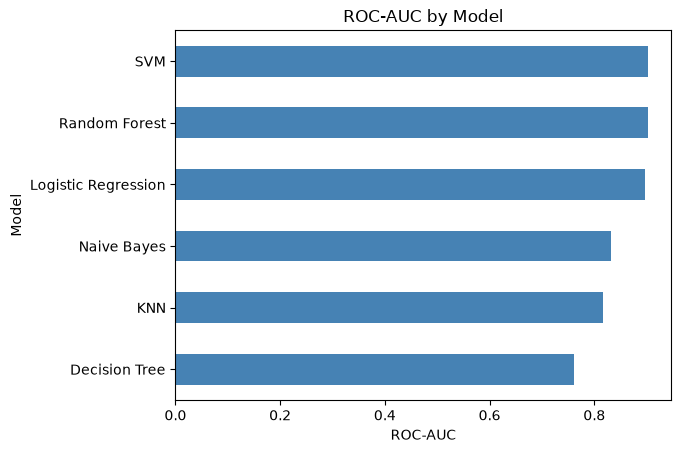

In [478]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions and probabilities for each model
models = {
    "Logistic Regression": (y_pred_log, y_prob_log),
    "KNN": (y_pred_knn, y_prob_knn),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "SVM": (y_pred_svm, y_prob_svm),
    "Naive Bayes": (y_pred_nb, y_prob_nb)
}

rows = []
for name, (pred, prob) in models.items():
    rows.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

compare_df = pd.DataFrame(rows, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])
print(compare_df.sort_values("ROC_AUC", ascending=False).round(3))

# Bar plot of ROC-AUC
compare_df.set_index("Model")["ROC_AUC"].sort_values().plot(kind="barh", color="steelblue")
plt.title("ROC-AUC by Model")
plt.xlabel("ROC-AUC")
plt.show()

In [479]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified CV on the training data only (test set stays untouched)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model
}

rows = []
for name, model in all_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    rows.append([name, scores.mean(), scores.std()])

cv_df = pd.DataFrame(rows, columns=["Model", "CV_ROC_AUC_mean", "CV_ROC_AUC_std"])
print(cv_df.sort_values("CV_ROC_AUC_mean", ascending=False).round(3))

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `Cal

                 Model  CV_ROC_AUC_mean  CV_ROC_AUC_std
3        Random Forest            0.881           0.029
0  Logistic Regression            0.880           0.018
4                  SVM            0.878           0.024
5          Naive Bayes            0.806           0.029
1                  KNN            0.803           0.036
2        Decision Tree            0.713           0.035


In [480]:
from sklearn.model_selection import GridSearchCV

# Parameter grid (classifier__ prefix = step name inside the pipeline)
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV ROC-AUC:", round(grid_rf.best_score_, 3))

Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.885


In [481]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Random sampling from continuous ranges for C and gamma
param_dist_svm = {
    "classifier__C": loguniform(0.1, 100),
    "classifier__gamma": loguniform(0.001, 1),
    "classifier__kernel": ["rbf", "linear"]
}

random_svm = RandomizedSearchCV(
    svm_model,
    param_dist_svm,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_svm.fit(X_train, y_train)

print("Best parameters:", random_svm.best_params_)
print("Best CV ROC-AUC:", round(random_svm.best_score_, 3))

Best parameters: {'classifier__C': np.float64(0.35498788321965025), 'classifier__gamma': np.float64(0.008179499475211672), 'classifier__kernel': 'linear'}
Best CV ROC-AUC: 0.881


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [482]:
# Best model found by GridSearchCV (already refit on the full training set)
best_model = grid_rf.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred_best), 3))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=["no appendicitis", "appendicitis"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_best), 3))

Test accuracy: 0.814
[[45 18]
 [11 82]]
                 precision    recall  f1-score   support

no appendicitis       0.80      0.71      0.76        63
   appendicitis       0.82      0.88      0.85        93

       accuracy                           0.81       156
      macro avg       0.81      0.80      0.80       156
   weighted avg       0.81      0.81      0.81       156

ROC-AUC: 0.892


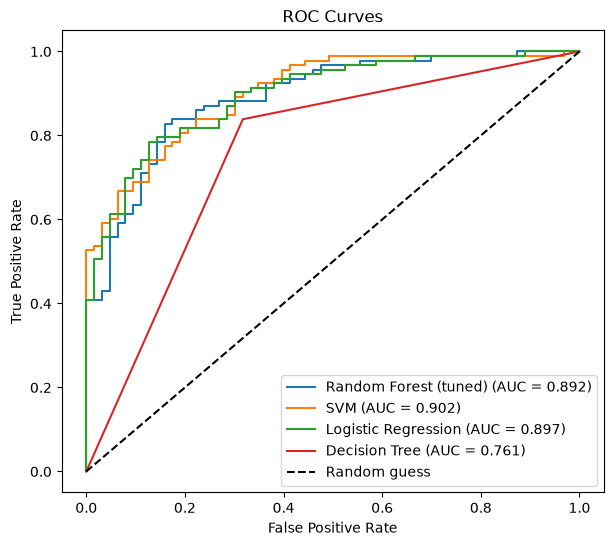

In [483]:
from sklearn.metrics import roc_curve

# ROC curves on the test set
plt.figure(figsize=(7, 6))

roc_models = {
    "Random Forest (tuned)": y_prob_best,
    "SVM": y_prob_svm,
    "Logistic Regression": y_prob_log,
    "Decision Tree": y_prob_tree
}

for name, prob in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# Diagonal line = random guessing
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

                             Feature  Importance
7         binary__Appendix_on_US_yes       0.247
5                   numeric__CRP_log       0.150
3                 numeric__WBC_Count       0.147
22          peritonitis__Peritonitis       0.086
4     numeric__Neutrophil_Percentage       0.080
1                       numeric__BMI       0.054
0                       numeric__Age       0.041
2          numeric__Body_Temperature       0.040
14          binary__Neutrophilia_yes       0.030
17           binary__Free_Fluids_yes       0.018
19           urine__Ketones_in_Urine       0.012
9   binary__Lower_Right_Abd_Pain_yes       0.011
20               urine__RBC_in_Urine       0.011
12                binary__Nausea_yes       0.010
13      binary__Loss_of_Appetite_yes       0.009


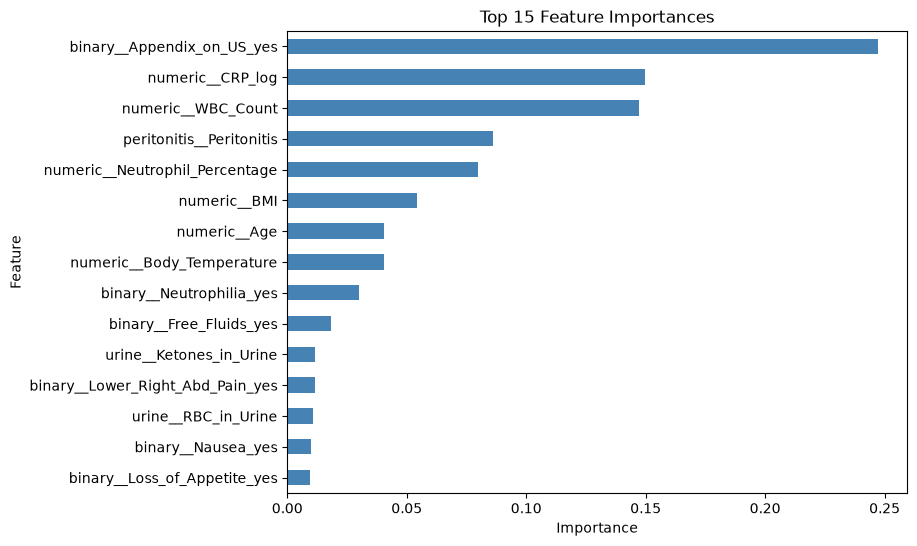

In [484]:
# Feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Importance values from the forest
importances = best_model.named_steps["classifier"].feature_importances_

imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
imp_df = imp_df.sort_values("Importance", ascending=False)
print(imp_df.head(15).round(3))

# Plot top 15
imp_df.head(15).sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance", figsize=(8, 6), legend=False, color="steelblue"
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [485]:
import joblib

# Save the full pipeline (preprocessing + tuned Random Forest)
joblib.dump(best_model, "best_appendicitis_model.joblib")

# Reload and confirm it gives the same test accuracy
loaded_model = joblib.load("best_appendicitis_model.joblib")
print("Reloaded test accuracy:", round(accuracy_score(y_test, loaded_model.predict(X_test)), 3))

Reloaded test accuracy: 0.814


In [486]:
print(compare_df.sort_values("ROC_AUC", ascending=False).round(3))
print(cv_df.sort_values("CV_ROC_AUC_mean", ascending=False).round(3))
print("Best RF params:", grid_rf.best_params_)
print("Tuned RF test accuracy:", round(accuracy_score(y_test, y_pred_best), 3))
print("Tuned RF test ROC-AUC:", round(roc_auc_score(y_test, y_prob_best), 3))
print(imp_df.head(10).round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
4                  SVM     0.788      0.806   0.849  0.827    0.902
3        Random Forest     0.840      0.840   0.903  0.870    0.902
0  Logistic Regression     0.808      0.818   0.871  0.844    0.897
5          Naive Bayes     0.571      0.964   0.290  0.446    0.831
1                  KNN     0.756      0.778   0.828  0.802    0.817
2        Decision Tree     0.776      0.796   0.839  0.817    0.761
                 Model  CV_ROC_AUC_mean  CV_ROC_AUC_std
3        Random Forest            0.881           0.029
0  Logistic Regression            0.880           0.018
4                  SVM            0.878           0.024
5          Naive Bayes            0.806           0.029
1                  KNN            0.803           0.036
2        Decision Tree            0.713           0.035
Best RF params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Tuned RF test accur